In [ ]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_curve, auc, confusion_matrix, balanced_accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import seaborn as sns
import gc
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
import pandas as pd
import shutil
from collections import defaultdict

# Set GPU memory growth to avoid allocating all memory at once
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Set GPU memory growth
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Found {len(gpus)} GPU devices and enabled memory growth")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")


TRAIN_DATA_DIR = '../../projectdata/images/100_stratified4fold_1000per_seed3888'
TEST_DATA_DIR = '../../projectdata/images/uncentred_ternary_224_ALL'

SEED = 3888
def set_seed(seed=3888):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
set_seed(SEED)

# Define image size and batch size
IMG_SIZE = 224  # Standard input size for ResNet50
BATCH_SIZE = 32

Found 1 GPU devices and enabled memory growth


In [2]:
type_to_label_map = {
    'Empty': 0,
    'Non-Tumor': 1,
    'Tumor': 2
}

In [3]:
def preprocess_image(img_path, target_size=(224, 224)):
    img = Image.open(img_path)
    img = img.resize(target_size)
    img_array = np.array(img, dtype=np.float32)
    img_array = img_array / 255.0
    
    return img_array

In [4]:
def load_data(dir, target_size=(224, 224)):
    X_data = []
    y_data = []
    

    for quadrant in os.listdir(dir):
        quadrant_path = os.path.join(dir, quadrant)
        X_data_quadrant = []
        y_data_quadrant = []
        
        for cell_type in os.listdir(quadrant_path):
            cell_type_path = os.path.join(quadrant_path, cell_type)
            # print(f"Processing quadrant: {quadrant}, cell type: {cell_type}")
            
            if os.path.isdir(cell_type_path):
                for filename in os.listdir(cell_type_path):
                    if filename.endswith(".png") or filename.endswith(".jpg"):
                        img_path = os.path.join(cell_type_path, filename)
                        img = preprocess_image(img_path, target_size=target_size)
                        # print(img.shape)
                        # print(is_cancer_cell[cell_type])
                        # print(f"Processing image: {img_path}\n")
                        
                        X_data_quadrant.append(img)
                        y_data_quadrant.append(type_to_label_map[cell_type])  
                        
        X_data.append(np.array(X_data_quadrant))
        y_data.append(np.array(y_data_quadrant))

    
    return (X_data, y_data)

def load_test_data(dir, quadrant, target_size=(224, 224)):
    """Load test data from a directory without separating by quadrants"""
    X_id = []
    X_test = []
    y_test = []
    

    quadrant_path = os.path.join(dir, quadrant)
    
    # Go through each cell type in the quadrant
    for cell_type in os.listdir(quadrant_path):
        cell_type_path = os.path.join(quadrant_path, cell_type)
        if os.path.isdir(cell_type_path):
            for filename in os.listdir(cell_type_path):
                if filename.endswith(".png") or filename.endswith(".jpg"):
                    img_path = os.path.join(cell_type_path, filename)
                    img = preprocess_image(img_path, target_size=target_size)
                    
                    parts = filename.replace(".png", "").replace(".jpg", "").split("_")
                    grid_id = f"{parts[1]}_{parts[2]}"

                    X_id.append(grid_id)
                    X_test.append(img)
                    y_test.append(type_to_label_map[cell_type])

    return X_id, np.array(X_test), np.array(y_test)


In [5]:
def create_resnet_model(learning_rate=0.0001, input_shape=(224, 224, 3), seed=3888):
    K.clear_session()
    set_seed(seed)

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    return model

In [6]:
def train_model(X_datas, y_datas, model_func, model_name, epochs=15, batch_size=8, learning_rate=0.001):
    # Combine all 4 folds of data as training set
    X_train = np.concatenate(X_datas)
    y_train = np.concatenate(y_datas)
    
    # Convert to categorical format
    y_train_cat = to_categorical(y_train, num_classes=3)
    
    print(f"Complete training set shape: {X_train.shape}")
    print(f"Training set label distribution: {np.unique(y_train, return_counts=True)}")
    
    # Create model
    model = model_func(
        learning_rate=learning_rate,
        seed=SEED
    )
    
    # Add early stopping mechanism
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    # Add model checkpoint for saving
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f"{model_name}.h5",
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
    
    # Train model
    history = model.fit(
        X_train, y_train_cat,
        validation_split=0.1,  # Use 10% of data as validation set
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )
    
    # Save final model
    # model.save(f"{model_name}_final.h5")
    # print(f"Model saved as {model_name}_final.h5 and {model_name}_best.h5 (best validation accuracy)")
    
    # Plot learning curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Return trained model and history
    return model, history

def evaluate_model(model, X_test, y_test):
    # One-hot encode the test labels
    model = load_model(model)
    y_test_cat = to_categorical(y_test, num_classes=3)
    
    print(f"Test set shape: {X_test.shape}")
    print(f"Label distribution in test set: {np.unique(y_test, return_counts=True)}")
    
    # Make predictions
    y_prob = model.predict(X_test)
    y_pred = np.argmax(y_prob, axis=1)
    
    # Compute evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    # Display evaluation results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=['Empty', 'Non-Tumor', 'Tumor'],
                                zero_division=0))
    
    # Optionally visualize the confusion matrix
    # import matplotlib.pyplot as plt
    # import seaborn as sns
    # plt.figure(figsize=(8, 6))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    #             xticklabels=['Non-Tumor', 'Tumor', 'Empty'], 
    #             yticklabels=['Non-Tumor', 'Tumor', 'Empty'])
    # plt.xlabel('Predicted Label')
    # plt.ylabel('True Label')
    # plt.tight_layout()
    # plt.show()
    
    # Save results in a dictionary
    results = {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'confusion_matrix': cm,
        'y_true': y_test,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    return results


def summarize_quadrant_results(results):
    """
    Summarize evaluation results across all quadrants
    
    Parameters:
        results: Dictionary with quadrants as keys and result dictionaries as values
    """
    all_y_true = np.concatenate([r['y_true'] for r in results.values()])
    all_y_pred = np.concatenate([r['y_pred'] for r in results.values()])
    
    # Calculate overall metrics
    overall_accuracy = accuracy_score(all_y_true, all_y_pred)
    overall_balanced_acc = balanced_accuracy_score(all_y_true, all_y_pred)
    overall_f1 = f1_score(all_y_true, all_y_pred, average='weighted')
    overall_precision = precision_score(all_y_true, all_y_pred, average='weighted', zero_division=0)
    overall_recall = recall_score(all_y_true, all_y_pred, average='weighted', zero_division=0)
    overall_cm = confusion_matrix(all_y_true, all_y_pred)
    
    print("\n==== OVERALL EVALUATION ACROSS ALL QUADRANTS ====")
    print(f"Total samples: {len(all_y_true)}")
    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    print(f"Overall Balanced Accuracy: {overall_balanced_acc:.4f}")
    print(f"Overall F1 Score: {overall_f1:.4f}")
    print(f"Overall Precision: {overall_precision:.4f}")
    print(f"Overall Recall: {overall_recall:.4f}")
    print("Overall Confusion Matrix:")
    print(overall_cm)
    print("\nOverall Classification Report:")
    print(classification_report(all_y_true, all_y_pred, 
                                target_names=['Empty', 'Non-Tumor', 'Tumor'],
                                zero_division=0))
    
    # Visualize the overall confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Empty', 'Non-Tumor', 'Tumor'], 
                yticklabels=['Empty', 'Non-Tumor', 'Tumor'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Overall Confusion Matrix Across All Quadrants')
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': overall_accuracy,
        'balanced_accuracy': overall_balanced_acc,
        'f1_score': overall_f1,
        'precision': overall_precision,
        'recall': overall_recall,
        'confusion_matrix': overall_cm,
        'y_true': all_y_true,
        'y_pred': all_y_pred
    }

In [ ]:
# Run four-quadrant cross validation
# Get previously loaded data
X_datas, y_datas = load_data(TRAIN_DATA_DIR)

# Set training parameters
params = {
    'epochs': 20,          # Number of training epochs
    'batch_size': 32,      # Batch size
    'learning_rate': 0.001, # Learning rate
}


for quadrant in range(0, 4):
    print(f"Processing quadrant: {quadrant + 1}")
    X_datas_rest = X_datas[:quadrant] + X_datas[quadrant+1:]
    y_datas_rest = y_datas[:quadrant] + y_datas[quadrant+1:]
    
    train_model(
        X_datas=X_datas_rest,
        y_datas=y_datas_rest,
        model_func=create_resnet_model,
        model_name=f"resnet50_fold_{quadrant+1}",
        **params
    )

Test set shape: (1004, 224, 224, 3)
Label distribution in test set: (array([0, 1, 2]), array([ 75, 618, 311], dtype=int64))
32/32 [==============================] - 4s 89ms/step
Accuracy: 0.3506
Balanced Accuracy: 0.3523
F1 Score: 0.2360
Precision: 0.6452
Recall: 0.3506
Confusion Matrix:
[[  0   0  75]
 [  0  47 571]
 [  0   6 305]]

Classification Report:
              precision    recall  f1-score   support

       Empty       0.00      0.00      0.00        75
   Non-Tumor       0.89      0.08      0.14       618
       Tumor       0.32      0.98      0.48       311

    accuracy                           0.35      1004
   macro avg       0.40      0.35      0.21      1004
weighted avg       0.65      0.35      0.24      1004

Accuracy: 0.3506
Balanced Accuracy: 0.3523
F1 Score: 0.2360
Precision: 0.6452
Recall: 0.3506
Confusion Matrix:
[[  0   0  75]
 [  0  47 571]
 [  0   6 305]]

Classification Report:
              precision    recall  f1-score   support

       Empty       0.00 

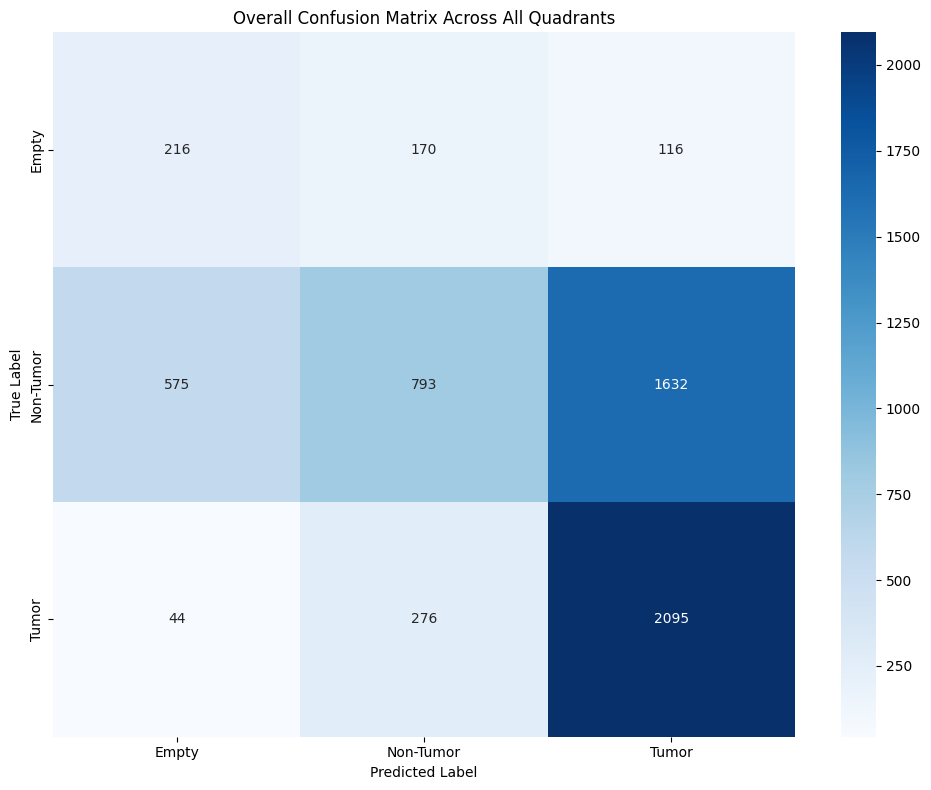

{'accuracy': 0.5245901639344263,
 'balanced_accuracy': 0.5207023472706827,
 'f1_score': 0.49038073176006663,
 'precision': 0.568951426327494,
 'recall': 0.5245901639344263,
 'confusion_matrix': array([[ 216,  170,  116],
        [ 575,  793, 1632],
        [  44,  276, 2095]], dtype=int64),
 'y_true': array([0, 0, 0, ..., 2, 2, 2]),
 'y_pred': array([2, 2, 2, ..., 2, 2, 2], dtype=int64)}

In [ ]:

quadrant_results = {}
for quadrant in range(0, 4):
    X_ids, X_test, y_test = load_test_data(TEST_DATA_DIR, f"Q{quadrant+1}", target_size=(224, 224))
    result = evaluate_model(f"resnet50_fold_{quadrant+1}.h5", X_test, y_test)
    quadrant_results[f"Q{quadrant+1}"] = result

summarize_quadrant_results(quadrant_results)